In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import OPTICS
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [45]:
class DataLoader:
    def __init__(self,data:str):
        self.data = pd.read_csv(data)

    def get_data(self):
        return self.data.head()

    def get_summary(self):
        return self.data.info()

class Preprocessing(DataLoader):
    def __init__(self,data:str):
        super().__init__(data)

    def delete_col(self,col:list):
        self.data = self.data.drop(columns=col)
        return self

    def transform_data(self):
        self.num_cols = self.data.select_dtypes(include=np.number).columns
        self.cat_cols = self.data.select_dtypes(include='object').columns

        num_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
        cat_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder",OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])
        self.preprocessor = ColumnTransformer(transformers=[
            ('num',num_pipeline,self.num_cols),
            ('cat',cat_pipeline,self.cat_cols)
        ])

        self.preprocessor.set_output(transform='pandas')
        self.data = self.preprocessor.fit_transform(self.data)
        return self.data

In [46]:
processor = Preprocessing('00.dataset/Mall_Customers.csv')

remove_columns = processor.delete_col(col=["CustomerID"])

df_clean = remove_columns.transform_data()

df_clean.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


In [47]:
class OPTICSGridSearch:
    def __init__(self,min_samples:int,xi:float,min_cluster_size:float):
        self.min_samples = min_samples
        self.xi = xi
        self.min_cluster_size = min_cluster_size

    def fit_evaluated(self,X,eps_range = np.arange(0.1, 1.6, 0.1)):
        self.df_scores = pd.DataFrame()
        X_arr = X.values if isinstance(X, pd.DataFrame) else X # Konversi ke numpy array jika input berupa DataFrame

        eps_values = []
        sil_scores = []
        ch_scores = []
        db_scores = []
        n_clusters_found = []

        for eps in eps_range:
            optics = OPTICS(min_samples=self.min_samples,xi=self.xi,min_cluster_size=self.min_cluster_size,max_eps=eps,)
            labels = optics.fit_predict(X_arr)

            core_mask = labels != -1  # Pisahkan noise (-1) dari klaster valid
            unique_labels = set(labels[core_mask])

            if len(unique_labels) >= 2:
                X_valid = X_arr[core_mask]
                labels_valid = labels[core_mask]

                eps_values.append(round(eps, 2))
                sil_scores.append(silhouette_score(X_valid, labels_valid))
                ch_scores.append(calinski_harabasz_score(X_valid, labels_valid))
                db_scores.append(davies_bouldin_score(X_valid, labels_valid))
                n_clusters_found.append(len(unique_labels))

                self.df_scores = pd.DataFrame({
                'Clusters Found': n_clusters_found,
                'eps': eps_values,
                'Silhouette Score': sil_scores,
                'Calinski-Harabasz Score': ch_scores,
                'Davies-Bouldin Score': db_scores,
                })

            if not self.df_scores.empty:
                scaler = MinMaxScaler()
                norm_sil = scaler.fit_transform(self.df_scores[['Silhouette Score']])
                norm_ch = scaler.fit_transform(self.df_scores[['Calinski-Harabasz Score']])
                norm_db = 1 - scaler.fit_transform(self.df_scores[['Davies-Bouldin Score']])
                self.df_scores['Composite_Score'] = (norm_sil + norm_ch + norm_db) / 3

        return self

    def plot_evaluation(self,figsize=(15, 11)):
        if not self.df_scores.empty:
            df = self.df_scores
            fig, axes = plt.subplots(2, 2, figsize=figsize)

            # --- Plot 1: Silhouette Score ---
            best_idx_sil = df['Silhouette Score'].idxmax()
            best_eps_sil = df.loc[best_idx_sil, 'eps']
            sns.lineplot(ax=axes[0, 0], x='eps',y='Silhouette Score',data=df,marker='o',color='#2b5c8f',)
            axes[0, 0].axvline(x=best_eps_sil,color='red',linestyle='--',label=f'Best max_eps = {best_eps_sil}',)
            axes[0, 0].set_title('Silhouette Score (Mendekati +1 Lebih Baik)', fontweight='bold')
            axes[0, 0].set_xlabel('Nilai max_eps')
            axes[0, 0].grid(True, linestyle=':', alpha=0.6)
            axes[0, 0].legend()

            # --- Plot 2: Calinski-Harabasz Score ---
            best_idx_ch = df['Calinski-Harabasz Score'].idxmax()
            best_eps_ch = df.loc[best_idx_ch, 'eps']
            sns.lineplot(ax=axes[0, 1], x='eps', y='Calinski-Harabasz Score', data=df, marker='s', color='#2e7d32')
            axes[0, 1].axvline(x=best_eps_ch, color='red', linestyle='--', label=f'Best max_eps = {best_eps_ch}')
            axes[0, 1].set_title('Calinski-Harabasz Score (Makin Tinggi Lebih Baik)', fontweight='bold')
            axes[0, 1].set_xlabel('Nilai max_eps')
            axes[0, 1].grid(True, linestyle=':', alpha=0.6)
            axes[0, 1].legend()
        
            # --- Plot 3: Davies-Bouldin Score ---
            best_idx_db = df['Davies-Bouldin Score'].idxmin()
            best_eps_db = df.loc[best_idx_db, 'eps']
            sns.lineplot(ax=axes[1, 0], x='eps', y='Davies-Bouldin Score', data=df, marker='^', color='#c62828')
            axes[1, 0].axvline(x=best_eps_db, color='green', linestyle='--', label=f'Best max_eps = {best_eps_db}')
            axes[1, 0].set_title('Davies-Bouldin Score (Makin Rendah Lebih Baik)', fontweight='bold')
            axes[1, 0].set_xlabel('Nilai max_eps')
            axes[1, 0].grid(True, linestyle=':', alpha=0.6)
            axes[1, 0].legend()
        
            # --- Plot 4: Composite Score ---
            best_idx_comp = df['Composite_Score'].idxmax()
            best_eps_comp = df.loc[best_idx_comp, 'eps']
            sns.lineplot(ax=axes[1, 1], x='eps', y='Composite_Score', data=df, marker='D', color='#7b1fa2')
            axes[1, 1].axvline(x=best_eps_comp, color='purple', linestyle='--', label=f'Rekomendasi max_eps = {best_eps_comp}')
            axes[1, 1].set_title('Normalized Composite Score (Gabungan 3 Metrik)', fontweight='bold')
            axes[1, 1].set_xlabel('Nilai max_eps')
            axes[1, 1].grid(True, linestyle=':', alpha=0.6)
            axes[1, 1].legend()

            plt.suptitle('Evaluasi Metrik Klastering OPTICS Berdasarkan max_eps', fontsize=14, fontweight='bold', y=0.98)
            plt.tight_layout()
            plt.show()
        else:
            print('Tidak ada kombinasi yang menghasilkan minimal 2 cluster non-noise.')

    def get_best_params(self):
        if not self.df_scores.empty:
            best_idx = self.df_scores['Composite_Score'].idxmax()
            return self.df_scores.loc[best_idx].to_dict()
        return None


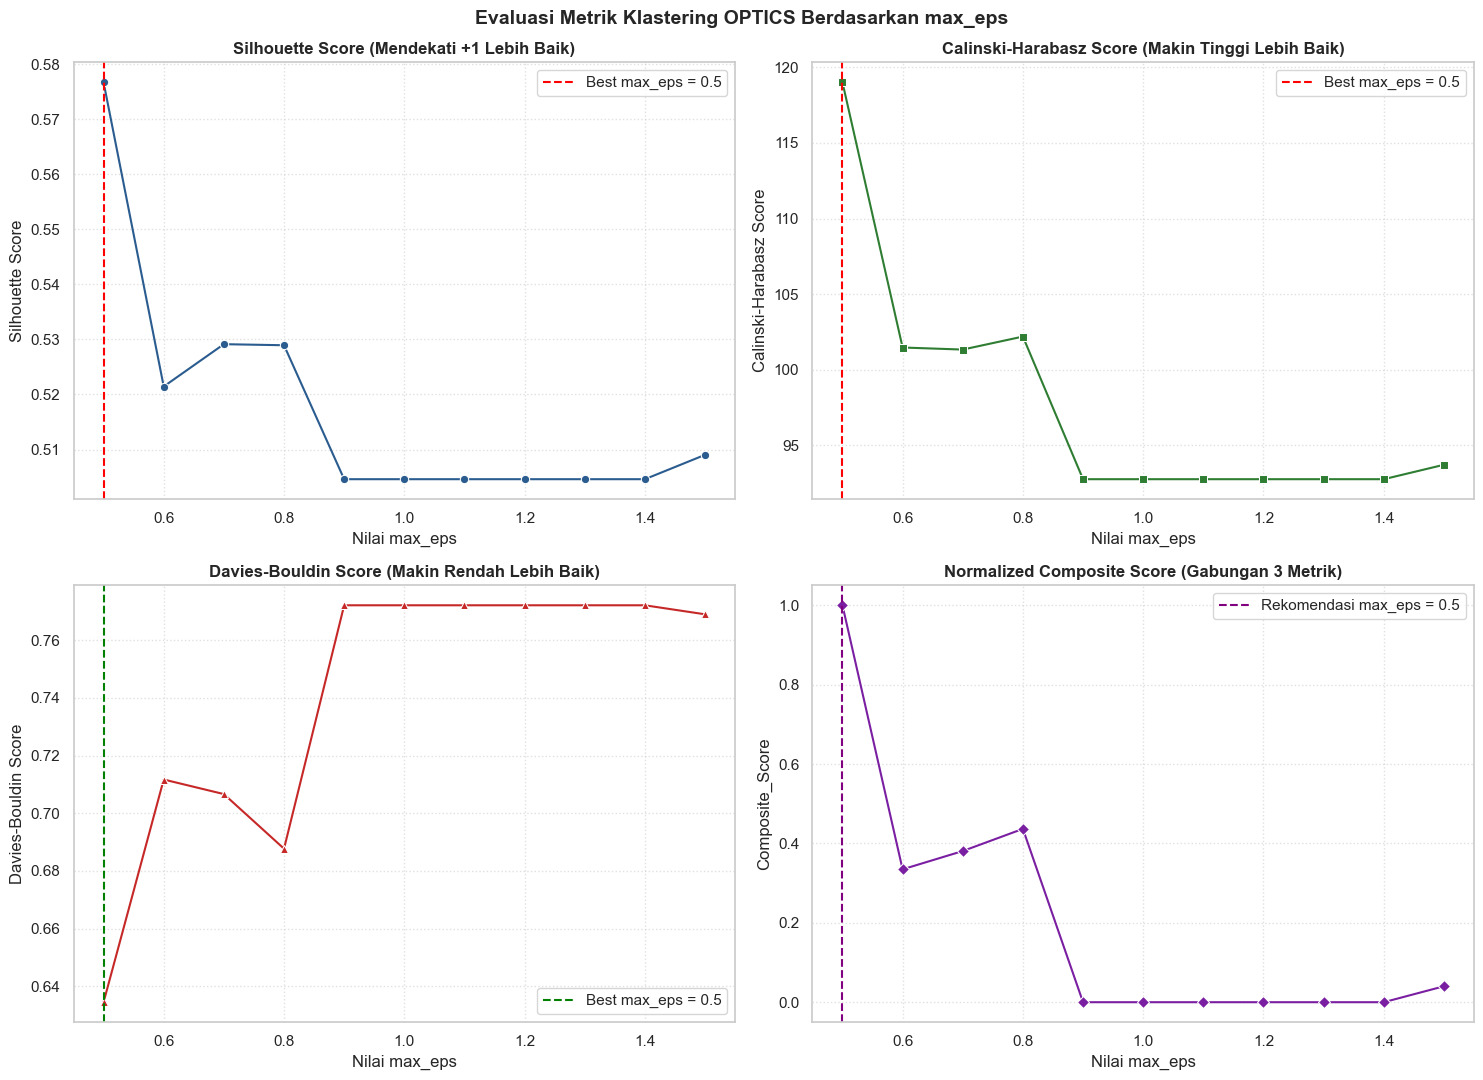

Best Configuration: {'Clusters Found': 4.0, 'eps': 0.5, 'Silhouette Score': 0.5766822276700605, 'Calinski-Harabasz Score': 119.01298271503454, 'Davies-Bouldin Score': 0.6344756000459884, 'Composite_Score': 1.0000000000000002}


In [48]:
evaluator = OPTICSGridSearch(min_samples=5, xi=0.05, min_cluster_size=0.05)

# Fit data dengan custom range eps
model = evaluator.fit_evaluated(df_clean, eps_range=np.arange(0.1, 1.6, 0.1))

# Tampilkan plot
model.plot_evaluation()

# Dapatkan parameter rekomendasi terbaik
best_config = model.get_best_params()
print('Best Configuration:', best_config)

In [49]:
class OPTICSClusterer:
    def __init__(self, max_eps: float, xi: float, min_cluster_size: float, min_samples: int = None):
        self.max_eps = max_eps
        self.xi = xi
        self.min_cluster_size = min_cluster_size
        self.min_samples = min_samples
        self.model = None

    def fit_predict(self, df: pd.DataFrame, X_features: pd.DataFrame, cluster_col: str = 'Cluster'):
        df_result = df.copy()
        X_arr = X_features.values if isinstance(X_features, pd.DataFrame) else X_features
        if self.min_samples is None:
            dim = X_arr.shape[1]
            self.min_samples = 2 * dim
        self.model = OPTICS(min_samples=self.min_samples,max_eps=self.max_eps,xi=self.xi,min_cluster_size=self.min_cluster_size)
        df_result[cluster_col] = self.model.fit_predict(X_arr)
        return df_result


In [50]:
dim = df_clean.shape[1] 
min_samples_val = 2 * dim
best_eps = 0.7 

# 2. Inisialisasi Model OPTICS & Data
clusterer = OPTICSClusterer(max_eps=best_eps, xi=0.05, min_cluster_size=0.05,min_samples=min_samples_val)
df = DataLoader("00.dataset/Mall_Customers.csv").data

# 3. Fit & Predict (Pastikan df_final mengembalikan df + kolom 'Cluster')
df_final = clusterer.fit_predict(df, df_clean)

print(f"Epsilon Terbaik Hasil Grid Search: {best_eps}")
df_final.head()

Epsilon Terbaik Hasil Grid Search: 0.7


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,-1
2,3,Female,20,16,6,-1
3,4,Female,23,16,77,-1
4,5,Female,31,17,40,-1


In [51]:
class ClusterVisualizer:
    def __init__(self,random_state=42,palette='Set2'):
        self.random_state = random_state
        self.palette = palette

    def plot_customer_segmentation(self,df_final,X_cleaned):
        pca = PCA(n_components=2, random_state=self.random_state)
        X_pca = pca.fit_transform(X_cleaned)

        df_pca = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
        df_pca["Cluster"] = df_final["Cluster"].values

        valid_clusters = df_pca[df_pca['Cluster'] != -1]
        centroids_pca = valid_clusters.groupby('Cluster')[['PCA1', 'PCA2']].mean().values

        sns.set_theme(style="whitegrid")
        palette = 'Set2'
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        sns.scatterplot(ax=axes[0],x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette=palette, s=90, alpha=0.8, style='Cluster')
        axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=250, c='red', marker='X', edgecolor='black', linewidth=1.5, label='Centroids') # Plot Centroid
        axes[0].set_title('Visualisasi Klaster (PCA 2D Projection)', fontsize=13, fontweight='bold', pad=12)
        axes[0].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
        axes[0].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
        axes[0].legend(title='Cluster', loc='upper right')

        sns.scatterplot( ax=axes[1],x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_final,  palette=self.palette, s=90, style='Cluster')
        axes[1].set_title('Segmentasi Pelanggan: Income vs Spending', fontsize=13, fontweight='bold', pad=12)
        axes[1].set_xlabel('Annual Income (k$)')
        axes[1].set_ylabel('Spending Score (1-100)')
        axes[1].legend(title='Cluster', loc='upper right')

        plt.suptitle('Analisis Visualisasi Klastering Pelanggan', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()


class CustomerProfileVisualizer(ClusterVisualizer):
    def __init__(self, random_state=42, palette='Set2'):
        super().__init__(random_state, palette)

    def plot_cluster_profiles(self, df, num_cols, min_samples_val=None):
        df_profile = df.groupby("Cluster")[num_cols].mean().reset_index()

        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4.5))

        for i, col in enumerate(num_cols):
            sns.barplot(ax=axes[i], x='Cluster', y=col, data=df_profile,hue='Cluster',legend=False,palette=self.palette, edgecolor='black', alpha=0.85)
            axes[i].set_title(f'Rata-Rata {col}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Cluster')
            axes[i].set_ylabel('Rata-Rata')
            for p in axes[i].patches: # Menambahkan label nilai angka di atas bar
                axes[i].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

        plt.suptitle(f'Analisis Karakteristik Pelanggan Per Klaster (k={min_samples_val})', fontsize=15, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()

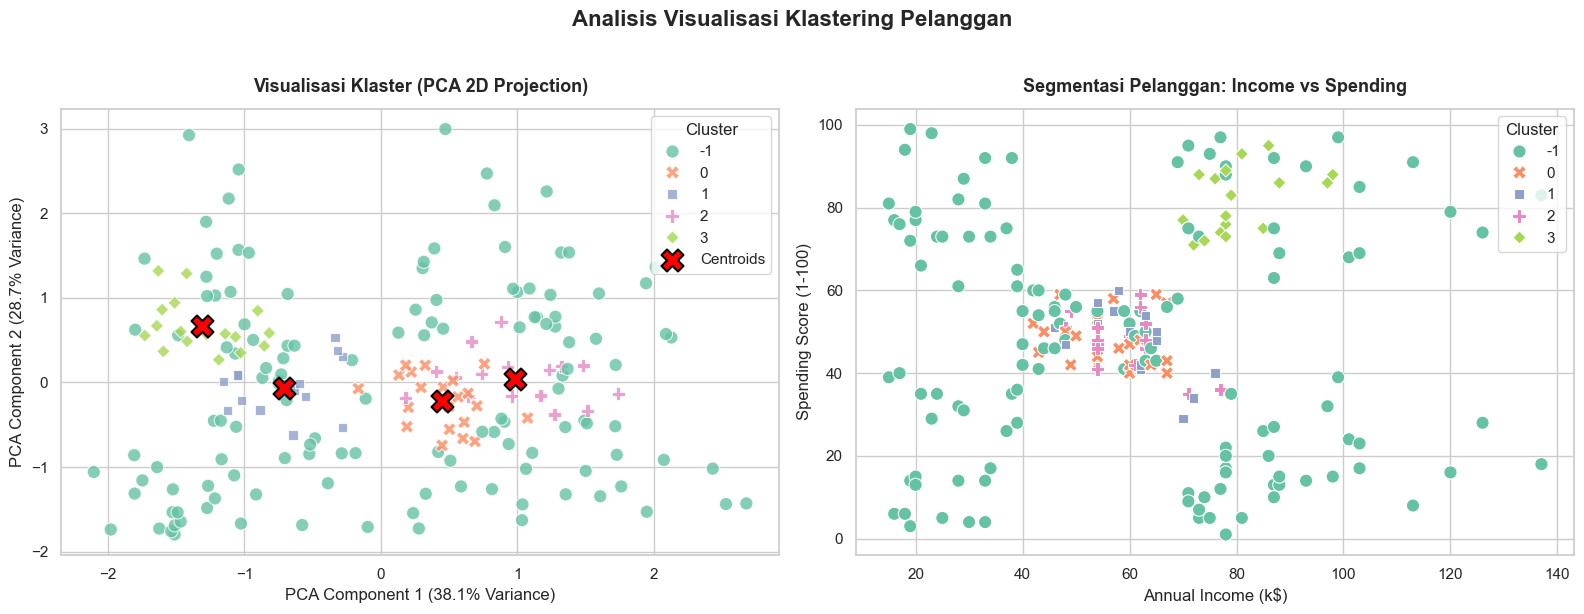

In [52]:
profiler = CustomerProfileVisualizer()
profiler.plot_customer_segmentation(df_final=df_final,X_cleaned=df_clean)

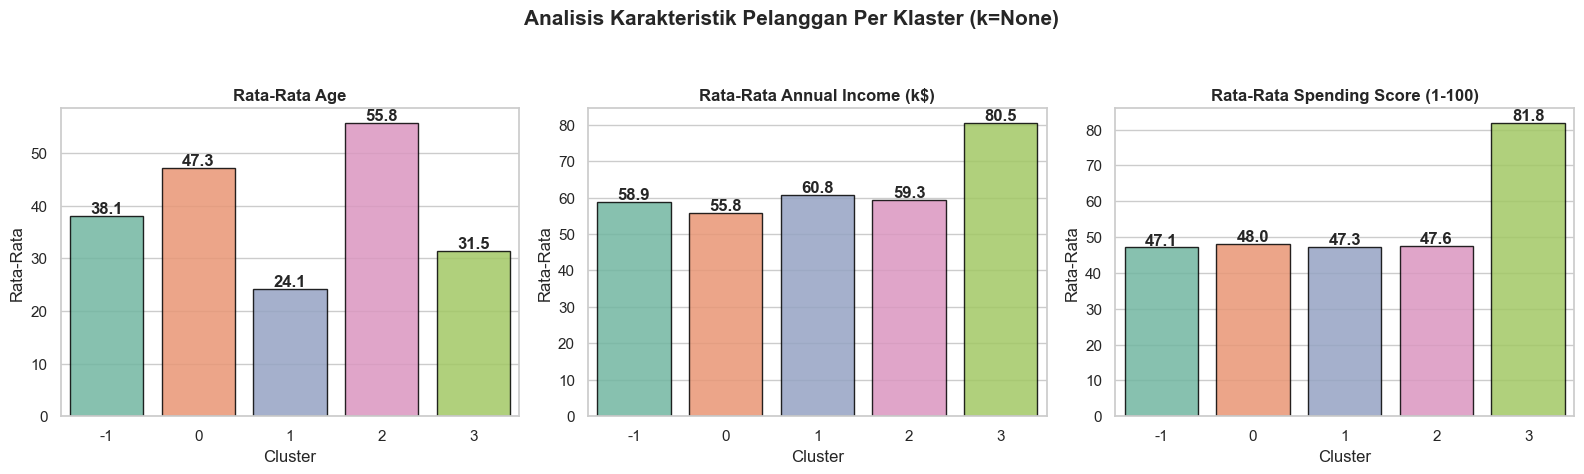

In [53]:
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
profiler.plot_cluster_profiles(df_final, num_cols)